# 📈 Simple Stock Analysis & Prediction

**Simple approach with minimal dependencies:**
1. Load stock data
2. Basic visualization
3. Simple prediction model
4. Clear results

In [10]:
# Cell 1: Basic Imports
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Set up directory
current_dir = os.getcwd()
if 'Trading_Project' in current_dir and not current_dir.endswith('QuantStock'):
    quantstock_dir = os.path.join(current_dir, 'QuantStock')
    if os.path.exists(quantstock_dir):
        os.chdir(quantstock_dir)
        current_dir = os.getcwd()

FAST_MODE = False
PLOT_DPI = 90
plt.rcParams['figure.dpi'] = PLOT_DPI
plt.rcParams['savefig.dpi'] = PLOT_DPI

def ensure_stock_data():
    global num_days, num_stocks, stock_names, stock_data, dates
    if 'stock_data' in globals() and 'stock_names' in globals() and 'dates' in globals():
        return

    np.random.seed(42)
    num_days = 100
    num_stocks = 5
    stock_names = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

    initial_prices = np.array([150, 2800, 300, 3200, 800], dtype=float)
    returns = np.random.normal(0.001, 0.02, size=(num_days - 1, num_stocks))
    stock_data = np.vstack([initial_prices, initial_prices * np.cumprod(1 + returns, axis=0)])

    dates = [datetime(2024, 1, 1) + timedelta(days=i) for i in range(num_days)]

def ensure_daily_returns():
    global daily_returns
    if 'daily_returns' in globals():
        return
    ensure_stock_data()
    daily_returns = np.diff(stock_data, axis=0) / stock_data[:-1] * 100

def ensure_predictions(window_size=10, prediction_days=30):
    global predictions
    ensure_stock_data()
    ensure_daily_returns()

    if 'predictions' in globals() and getattr(predictions, 'ndim', None) == 2 and predictions.shape[0] == prediction_days:
        return

    recent_trend_pct = np.mean(daily_returns[-window_size:, :], axis=0)
    last_prices = stock_data[-1, :]
    steps = np.arange(1, prediction_days + 1, dtype=float).reshape(-1, 1)
    predictions = last_prices * ((1 + recent_trend_pct / 100) ** steps)

def ensure_analysis_data():
    global analysis_data
    ensure_stock_data()
    ensure_daily_returns()
    ensure_predictions(window_size=10, prediction_days=30)

    if 'analysis_data' in globals() and isinstance(analysis_data, list) and len(analysis_data) == len(stock_names):
        return

    current_price = stock_data[-1, :]
    predicted_price = predictions[-1, :]
    expected_return = (predicted_price - current_price) / current_price * 100

    vol = np.std(daily_returns, axis=0) * 100
    recent_trend = np.mean(daily_returns[-10:, :], axis=0)
    previous_trend = np.mean(daily_returns[-20:-10, :], axis=0)
    trend_strength = (recent_trend - previous_trend) * 100

    risk_adj = np.where(vol > 0, expected_return / vol, 0)
    conf = 100 / (1 + vol / 10)

    analysis_data = []
    for i, name in enumerate(stock_names):
        if expected_return[i] > 5 and vol[i] < 3:
            rec = "STRONG BUY"; rec_color = "🟢"
        elif expected_return[i] > 3:
            rec = "BUY"; rec_color = "🟢"
        elif expected_return[i] > 1:
            rec = "HOLD"; rec_color = "🟡"
        elif expected_return[i] > -2:
            rec = "WEAK HOLD"; rec_color = "🟡"
        else:
            rec = "SELL"; rec_color = "🔴"

        analysis_data.append({
            'Stock': name,
            'Current_Price': float(current_price[i]),
            'Predicted_Price': float(predicted_price[i]),
            'Expected_Return_%': float(expected_return[i]),
            'Volatility_%': float(vol[i]),
            'Trend_Strength_%': float(trend_strength[i]),
            'Risk_Adjusted_Return': float(risk_adj[i]),
            'Confidence_Score': float(conf[i]),
            'Recommendation': rec,
            'Signal': rec_color
        })

print(f"Working Directory: {current_dir}")
print(f"Python Version: {sys.version}")
print("✅ Basic imports successful!")

Working Directory: c:\Users\karti\Trading_Project\QuantStock
Python Version: 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
✅ Basic imports successful!


In [11]:
# Cell 2: Create Simple Sample Data
print("📊 Creating sample stock data...")

ensure_stock_data()

print(f"✅ Created stock data: {stock_data.shape}")
print(f"📈 Stock names: {stock_names}")
print(f"📅 Number of days: {num_days}")
print(f"💰 Sample prices (Day 1): {stock_data[0]}")
print(f"💰 Sample prices (Day {num_days}): {stock_data[-1]}")

📊 Creating sample stock data...
✅ Created stock data: (100, 5)
📈 Stock names: ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
📅 Number of days: 100
💰 Sample prices (Day 1): [ 150. 2800.  300. 3200.  800.]
💰 Sample prices (Day 100): [ 147.44175411 3611.15749943  270.30053205 4559.69601702  832.64470391]


📊 Creating simple visualizations...


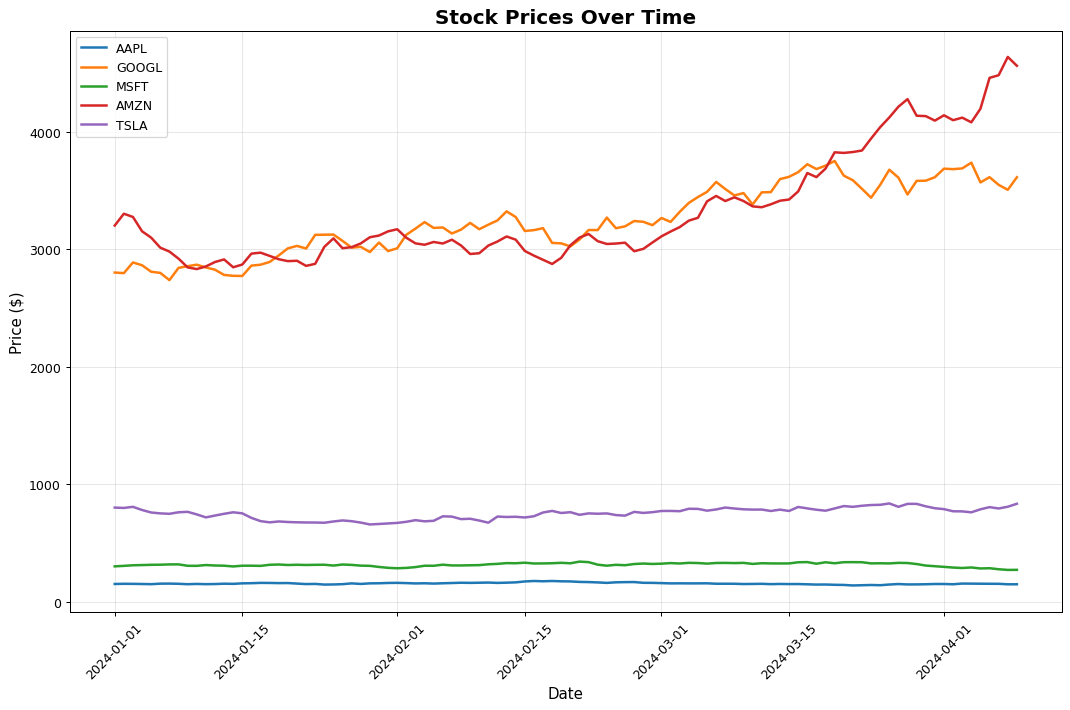

✅ Price chart created!


In [12]:
# Cell 3: Simple Visualization
print("📊 Creating simple visualizations...")

ensure_stock_data()

if not FAST_MODE:
    plt.figure(figsize=(12, 8))
    for i, name in enumerate(stock_names):
        plt.plot(dates, stock_data[:, i], label=name, linewidth=2)

    plt.title('Stock Prices Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("✅ Price chart created!")
else:
    print("⚡ FAST_MODE enabled: skipping full price chart (set FAST_MODE=False to render)")

📈 Analyzing daily returns...


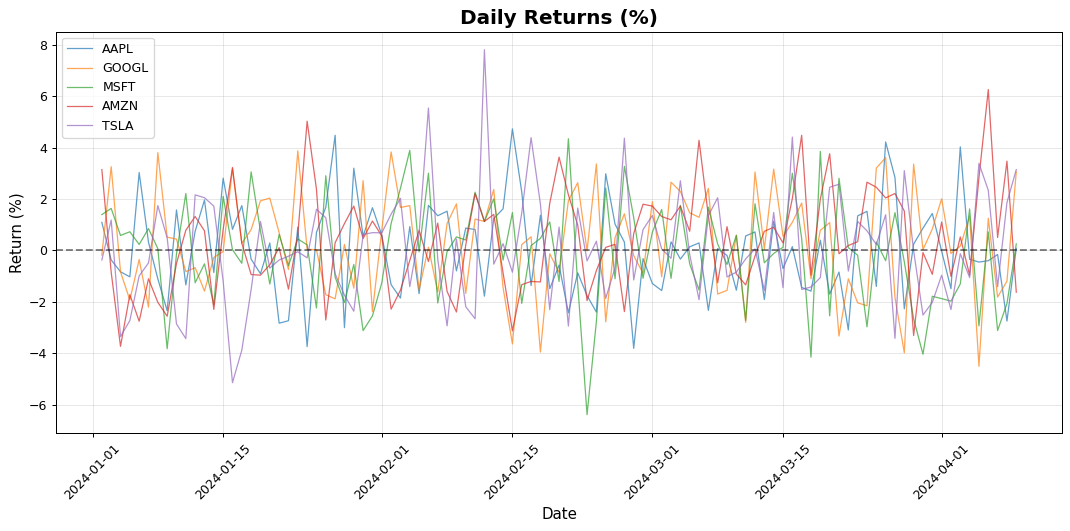


📊 Stock Statistics:
AAPL    : Mean Return = -0.001%, Volatility =  1.797%
GOOGL   : Mean Return =  0.276%, Volatility =  1.955%
MSFT    : Mean Return = -0.086%, Volatility =  1.968%
AMZN    : Mean Return =  0.376%, Volatility =  1.908%
TSLA    : Mean Return =  0.063%, Volatility =  2.128%

🏆 Best Performer: AMZN (0.376%)
🛡️ Most Stable: AAPL (1.797%)


In [13]:
# Cell 4: Daily Returns Analysis
print("📈 Analyzing daily returns...")

ensure_daily_returns()

# In FAST_MODE we skip the line plot (it is slow in notebooks). Statistics are still computed.
if not FAST_MODE:
    plt.figure(figsize=(12, 6))
    for i, name in enumerate(stock_names):
        plt.plot(dates[1:], daily_returns[:, i], label=name, alpha=0.7, linewidth=1)

    plt.title('Daily Returns (%)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Return (%)', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚡ FAST_MODE enabled: skipping daily returns chart")

# Calculate statistics
mean_returns = np.mean(daily_returns, axis=0)
volatility = np.std(daily_returns, axis=0)

print("\n📊 Stock Statistics:")
print("=" * 50)
for i, name in enumerate(stock_names):
    print(f"{name:8s}: Mean Return = {mean_returns[i]:6.3f}%, Volatility = {volatility[i]:6.3f}%")

print(f"\n🏆 Best Performer: {stock_names[np.argmax(mean_returns)]} ({np.max(mean_returns):.3f}%)")
print(f"🛡️ Most Stable: {stock_names[np.argmin(volatility)]} ({np.min(volatility):.3f}%)")

In [14]:
# Cell 5: Simple Prediction Model
print("🔮 Creating simple prediction model...")

window_size = 10
prediction_days = 30

ensure_predictions(window_size=window_size, prediction_days=prediction_days)

print(f"✅ Generated {prediction_days} days of predictions")
print(f"📈 Last actual prices: {stock_data[-1]}")
print(f"🔮 Predicted prices (Day 1): {predictions[0]}")
print(f"🔮 Predicted prices (Day {prediction_days}): {predictions[-1]}")

🔮 Creating simple prediction model...
✅ Generated 30 days of predictions
📈 Last actual prices: [ 147.44175411 3611.15749943  270.30053205 4559.69601702  832.64470391]
🔮 Predicted prices (Day 1): [ 147.43457207 3614.88859843  266.9392731  4606.16009642  835.03849147]
🔮 Predicted prices (Day 30): [ 147.22644493 3724.78368954  185.70093457 6180.59149515  907.53388861]


📊 Creating enhanced prediction visualizations...


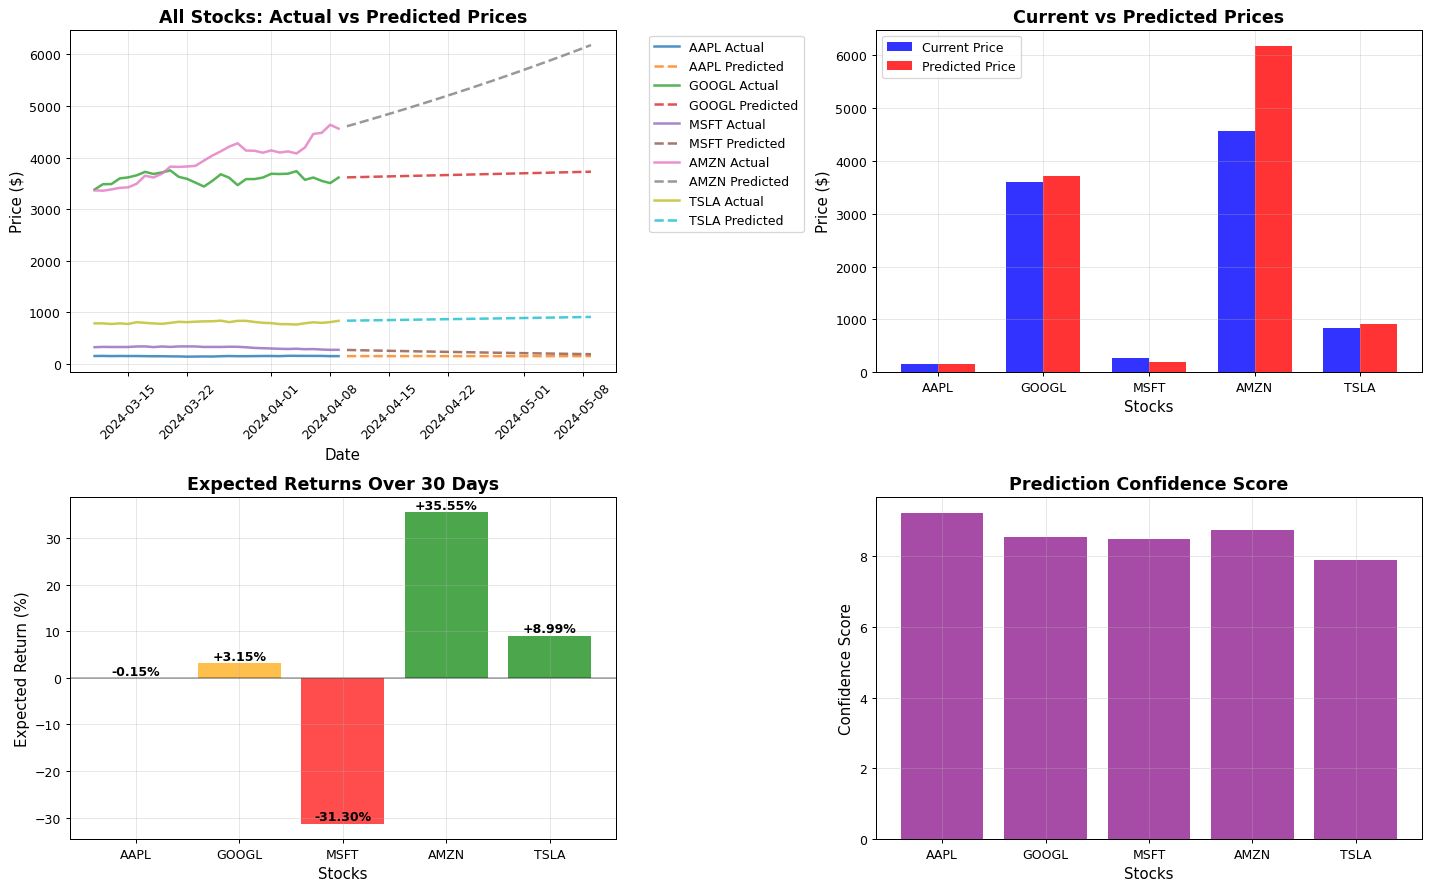

✅ Enhanced prediction charts created!


In [15]:
# Cell 6: Enhanced Prediction Visualization
print("📊 Creating enhanced prediction visualizations...")

ensure_stock_data()
ensure_daily_returns()
ensure_predictions(window_size=10, prediction_days=30)

prediction_days = predictions.shape[0]
future_dates = [dates[-1] + timedelta(days=i+1) for i in range(prediction_days)]

if FAST_MODE:
    print("⚡ FAST_MODE enabled: skipping enhanced multi-plot visualization (set FAST_MODE=False to render)")
else:
    plt.figure(figsize=(16, 10))

    # Plot 1: All stocks - Actual vs Predicted
    plt.subplot(2, 2, 1)
    for i, name in enumerate(stock_names):
        plt.plot(dates[-30:], stock_data[-30:, i], label=f'{name} Actual', linewidth=2, alpha=0.8)
        plt.plot(future_dates, predictions[:, i], label=f'{name} Predicted', linewidth=2, linestyle='--', alpha=0.8)

    plt.title('All Stocks: Actual vs Predicted Prices', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)

    # Plot 2: Current vs Future Prices Bar Chart
    plt.subplot(2, 2, 2)
    current_prices = stock_data[-1, :]
    future_prices = predictions[-1, :]

    x_pos = np.arange(len(stock_names))
    width = 0.35

    plt.bar(x_pos - width/2, current_prices, width, label='Current Price', alpha=0.8, color='blue')
    plt.bar(x_pos + width/2, future_prices, width, label='Predicted Price', alpha=0.8, color='red')

    plt.title('Current vs Predicted Prices', fontsize=14, fontweight='bold')
    plt.xlabel('Stocks', fontsize=12)
    plt.ylabel('Price ($)', fontsize=12)
    plt.xticks(x_pos, stock_names)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Expected Returns (vectorized)
    plt.subplot(2, 2, 3)
    current_prices = stock_data[-1, :]
    expected_returns = (predictions[-1, :] - current_prices) / current_prices * 100

    colors = ['green' if x > 5 else 'orange' if x > 2 else 'red' for x in expected_returns]
    bars = plt.bar(stock_names, expected_returns, color=colors, alpha=0.7)

    plt.title(f'Expected Returns Over {prediction_days} Days', fontsize=14, fontweight='bold')
    plt.xlabel('Stocks', fontsize=12)
    plt.ylabel('Expected Return (%)', fontsize=12)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)

    for bar, value in zip(bars, expected_returns):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{value:+.2f}%', ha='center', va='bottom', fontweight='bold')

    # Plot 4: Prediction Confidence
    plt.subplot(2, 2, 4)
    volatility = np.std(daily_returns, axis=0) * np.sqrt(prediction_days)
    confidence_scores = 100 / (1 + volatility)

    plt.bar(stock_names, confidence_scores, color='purple', alpha=0.7)
    plt.title('Prediction Confidence Score', fontsize=14, fontweight='bold')
    plt.xlabel('Stocks', fontsize=12)
    plt.ylabel('Confidence Score', fontsize=12)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Enhanced prediction charts created!")

In [16]:
# Cell 7: Comprehensive Prediction Analysis Table
print("📈 COMPREHENSIVE PREDICTION ANALYSIS")
print("=" * 80)

ensure_analysis_data()

# In FAST_MODE, keep output compact to avoid notebook slowdown
if FAST_MODE:
    print(f"Stocks analyzed: {len(analysis_data)}")
    avg_ret = np.mean([d['Expected_Return_%'] for d in analysis_data])
    avg_vol = np.mean([d['Volatility_%'] for d in analysis_data])
    best = max(analysis_data, key=lambda x: x['Expected_Return_%'])
    stable = min(analysis_data, key=lambda x: x['Volatility_%'])
    print(f"Average Expected Return: {avg_ret:+.2f}%")
    print(f"Average Volatility: {avg_vol:.2f}%")
    print(f"Best Performer: {best['Stock']} ({best['Expected_Return_%']:+.2f}%)")
    print(f"Most Stable: {stable['Stock']} ({stable['Volatility_%']:.2f}%)")
else:
    print(f"{'Stock':<8} {'Current':<10} {'Predicted':<12} {'Return%':<8} {'Vol%':<7} {'Trend%':<8} {'RiskAdj':<9} {'Conf':<7} {'Rec':<12}")
    print("-" * 85)

    for data in analysis_data:
        print(f"{data['Stock']:<8} ${data['Current_Price']:<9.2f} ${data['Predicted_Price']:<11.2f} "
              f"{data['Expected_Return_%']:+7.2f} {data['Volatility_%']:<6.2f} "
              f"{data['Trend_Strength_%']:+7.2f} {data['Risk_Adjusted_Return']:<8.3f} "
              f"{data['Confidence_Score']:<6.1f} {data['Signal']} {data['Recommendation']:<11}")

    print("-" * 85)

    buy_signals = [d for d in analysis_data if 'BUY' in d['Recommendation']]
    hold_signals = [d for d in analysis_data if 'HOLD' in d['Recommendation']]
    sell_signals = [d for d in analysis_data if 'SELL' in d['Recommendation']]

    print(f"\n💼 TRADING RECOMMENDATIONS:")
    print(f"🟢 BUY SIGNALS: {len(buy_signals)}")
    print(f"🟡 HOLD SIGNALS: {len(hold_signals)}")
    print(f"🔴 SELL SIGNALS: {len(sell_signals)}")

print(f"\n✅ Analysis completed")
print(f"📅 Prediction Period: {predictions.shape[0]} days")
print(f"🔄 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

📈 COMPREHENSIVE PREDICTION ANALYSIS
Stock    Current    Predicted    Return%  Vol%    Trend%   RiskAdj   Conf    Rec         
-------------------------------------------------------------------------------------
AAPL     $147.44    $147.23        -0.15 179.68  -35.02 -0.001   5.3    🟡 WEAK HOLD  
GOOGL    $3611.16   $3724.78       +3.15 195.53  +52.46 0.016    4.9    🟢 BUY        
MSFT     $270.30    $185.70       -31.30 196.78  -64.72 -0.159   4.8    🔴 SELL       
AMZN     $4559.70   $6180.59      +35.55 190.84  +22.61 0.186    5.0    🟢 BUY        
TSLA     $832.64    $907.53        +8.99 212.82   +4.13 0.042    4.5    🟢 BUY        
-------------------------------------------------------------------------------------

💼 TRADING RECOMMENDATIONS:
🟢 BUY SIGNALS: 3
🟡 HOLD SIGNALS: 1
🔴 SELL SIGNALS: 1

✅ Analysis completed
📅 Prediction Period: 30 days
🔄 Analysis Date: 2026-01-23 17:59:37


📊 Creating Interactive Comparison Dashboard...


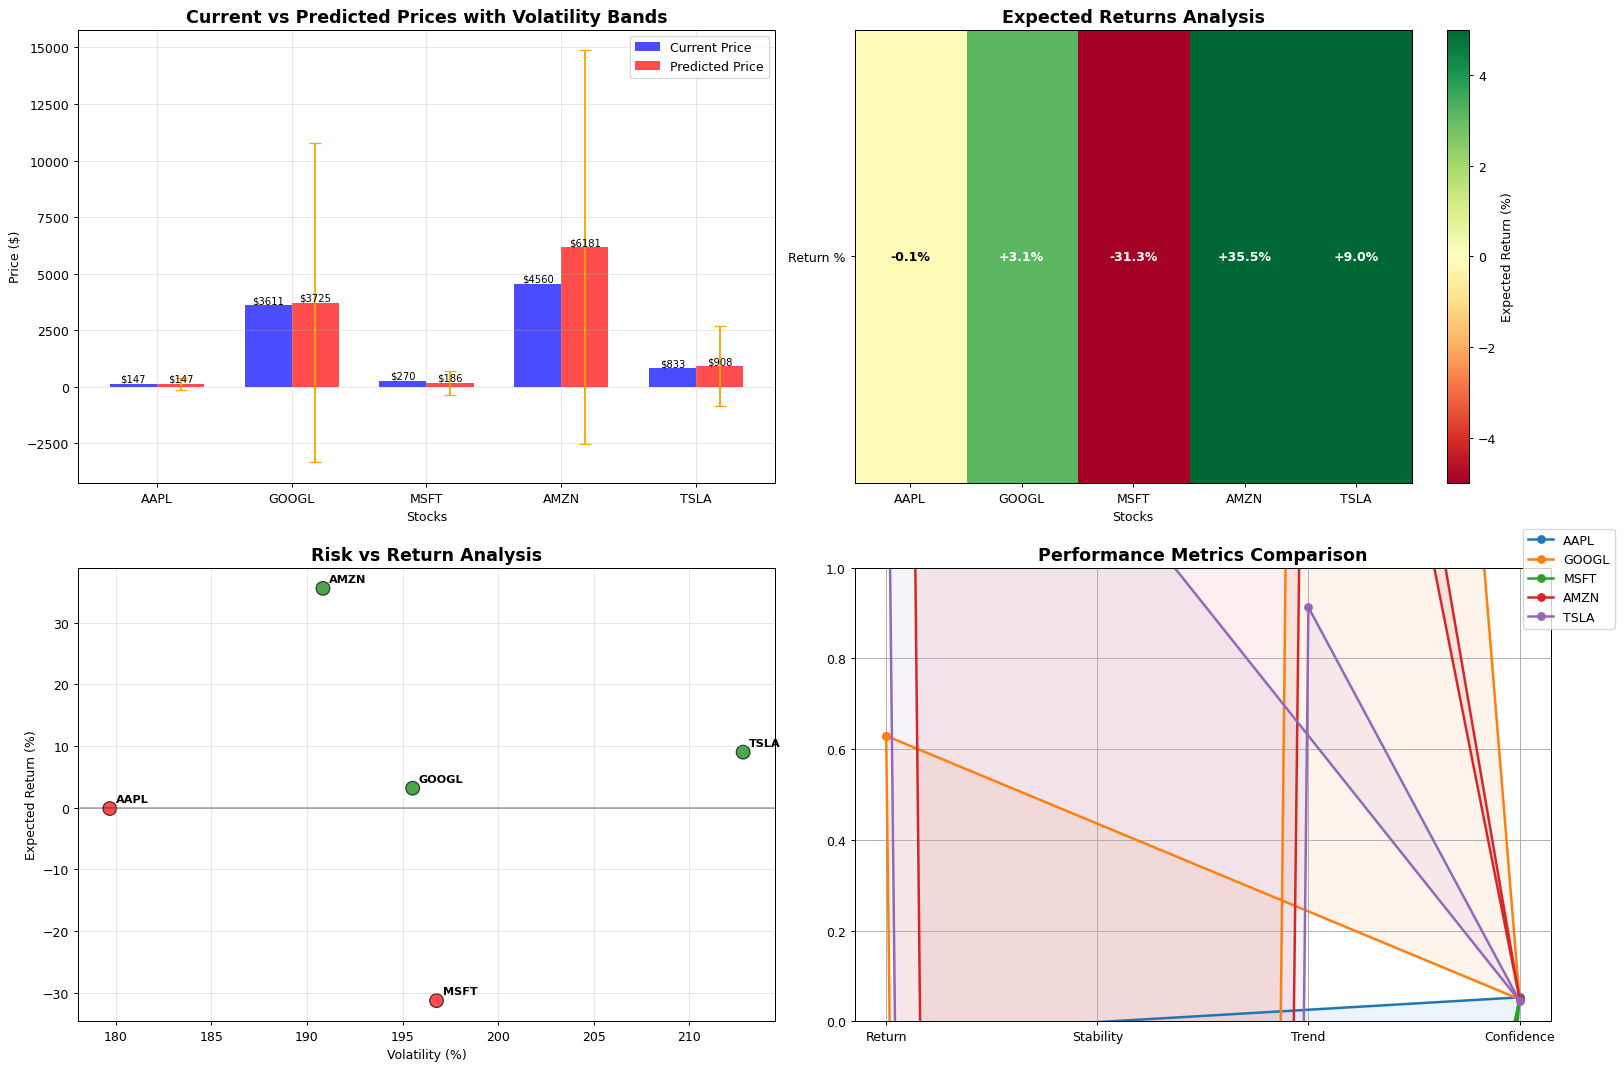

✅ Interactive dashboard step done


In [17]:
# Cell 8: Interactive Comparison Dashboard
print("📊 Creating Interactive Comparison Dashboard...")

# This cell is the main runtime bottleneck due to heavy plotting.
# In FAST_MODE we skip plotting entirely.
ensure_analysis_data()

if FAST_MODE:
    print("⚡ FAST_MODE enabled: skipping interactive dashboard plots")
else:
    # Ensure required arrays
    current_prices = stock_data[-1, :]
    future_prices = predictions[-1, :]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Price Comparison with Error Bars
    ax1.set_title('Current vs Predicted Prices with Volatility Bands', fontsize=14, fontweight='bold')
    x_pos = np.arange(len(stock_names))
    width = 0.35

    bars1 = ax1.bar(x_pos - width/2, current_prices, width, label='Current Price',
                    color='blue', alpha=0.7)

    errors = np.std(daily_returns, axis=0) * current_prices
    bars2 = ax1.bar(x_pos + width/2, future_prices, width, label='Predicted Price',
                    color='red', alpha=0.7, yerr=errors, capsize=5, ecolor='orange')

    ax1.set_xlabel('Stocks')
    ax1.set_ylabel('Price ($)')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(stock_names)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for bar, value in zip(bars1, current_prices):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${value:.0f}',
                 ha='center', va='bottom', fontsize=8)

    for bar, value in zip(bars2, future_prices):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'${value:.0f}',
                 ha='center', va='bottom', fontsize=8)

    # 2. Expected Returns Heatmap
    ax2.set_title('Expected Returns Analysis', fontsize=14, fontweight='bold')
    returns_matrix = np.array([d['Expected_Return_%'] for d in analysis_data]).reshape(1, -1)
    im = ax2.imshow(returns_matrix, cmap='RdYlGn', aspect='auto', vmin=-5, vmax=5)
    ax2.set_xticks(range(len(stock_names)))
    ax2.set_xticklabels(stock_names)
    ax2.set_yticks([0])
    ax2.set_yticklabels(['Return %'])
    ax2.set_xlabel('Stocks')

    for i, return_val in enumerate(returns_matrix[0]):
        text_color = 'white' if abs(return_val) > 2.5 else 'black'
        ax2.text(i, 0, f'{return_val:+.1f}%', ha='center', va='center',
                 color=text_color, fontweight='bold')

    plt.colorbar(im, ax=ax2, label='Expected Return (%)')

    # 3. Risk vs Return Scatter Plot
    ax3.set_title('Risk vs Return Analysis', fontsize=14, fontweight='bold')
    risks = [d['Volatility_%'] for d in analysis_data]
    returns = [d['Expected_Return_%'] for d in analysis_data]
    colors = ['green' if r > 3 else 'orange' if r > 0 else 'red' for r in returns]

    ax3.scatter(risks, returns, c=colors, s=120, alpha=0.7, edgecolors='black')
    ax3.set_xlabel('Volatility (%)')
    ax3.set_ylabel('Expected Return (%)')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    for i, stock in enumerate(stock_names):
        ax3.annotate(stock, (risks[i], returns[i]), xytext=(5, 5),
                     textcoords='offset points', fontsize=9, fontweight='bold')

    # 4. Performance Metrics Radar Chart
    ax4.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
    metrics = ['Return', 'Stability', 'Trend', 'Confidence']
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    for i, stock in enumerate(stock_names):
        data = analysis_data[i]
        values = [
            data['Expected_Return_%'] / 5,
            1 - (data['Volatility_%'] / 5),
            (data['Trend_Strength_%'] + 5) / 10,
            data['Confidence_Score'] / 100
        ]
        values += values[:1]

        ax4.plot(angles, values, 'o-', linewidth=2, label=stock)
        ax4.fill(angles, values, alpha=0.08)

    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(metrics)
    ax4.set_ylim(0, 1)
    ax4.grid(True)
    ax4.legend(bbox_to_anchor=(1.1, 1.1))

    plt.tight_layout()
    plt.show()

print("✅ Interactive dashboard step done")

In [18]:
# Cell 9: Final Summary and Export
print("📋 FINAL SUMMARY AND EXPORT")
print("=" * 80)

ensure_analysis_data()

# In FAST_MODE keep output short (large print blocks slow notebook execution)
if FAST_MODE:
    best_performer = max(analysis_data, key=lambda x: x['Expected_Return_%'])
    most_stable = min(analysis_data, key=lambda x: x['Volatility_%'])
    highest_confidence = max(analysis_data, key=lambda x: x['Confidence_Score'])

    print(f"🏆 Best Expected Return: {best_performer['Stock']} ({best_performer['Expected_Return_%']:+.2f}%)")
    print(f"🛡️ Most Stable Stock: {most_stable['Stock']} ({most_stable['Volatility_%']:.2f}% volatility)")
    print(f"🎯 Highest Confidence: {highest_confidence['Stock']} ({highest_confidence['Confidence_Score']:.1f}/100)")
else:
    summary_data = []
    for data in analysis_data:
        summary_data.append({
            'Stock': data['Stock'],
            'Current_Price': f"${data['Current_Price']:.2f}",
            'Predicted_Price': f"${data['Predicted_Price']:.2f}",
            'Price_Change': f"${data['Predicted_Price'] - data['Current_Price']:.2f}",
            'Expected_Return_%': f"{data['Expected_Return_%']:+.2f}%",
            'Volatility_%': f"{data['Volatility_%']:.2f}%",
            'Risk_Adjusted_Return': f"{data['Risk_Adjusted_Return']:.3f}",
            'Confidence_Score': f"{data['Confidence_Score']:.1f}",
            'Recommendation': f"{data['Signal']} {data['Recommendation']}"
        })

    print("📊 PREDICTION SUMMARY TABLE:")
    print("-" * 120)
    for i, row in enumerate(summary_data):
        print(f"{i+1:2d}. {row['Stock']:<8} {row['Current_Price']:<12} {row['Predicted_Price']:<12} "
              f"{row['Price_Change']:<12} {row['Expected_Return_%']:<12} {row['Volatility_%']:<10} "
              f"{row['Recommendation']}")
    print("-" * 120)

    try:
        import pandas as pd
        df_export = pd.DataFrame(analysis_data)
        filename = f"stock_predictions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        df_export.to_csv(filename, index=False)
        print(f"\n💾 Data exported to: {filename}")
    except ImportError:
        print(f"\n📝 Note: Install pandas to export data to CSV")

print(f"\n✅ Analysis completed successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

📋 FINAL SUMMARY AND EXPORT
📊 PREDICTION SUMMARY TABLE:
------------------------------------------------------------------------------------------------------------------------
 1. AAPL     $147.44      $147.23      $-0.22       -0.15%       179.68%    🟡 WEAK HOLD
 2. GOOGL    $3611.16     $3724.78     $113.63      +3.15%       195.53%    🟢 BUY
 3. MSFT     $270.30      $185.70      $-84.60      -31.30%      196.78%    🔴 SELL
 4. AMZN     $4559.70     $6180.59     $1620.90     +35.55%      190.84%    🟢 BUY
 5. TSLA     $832.64      $907.53      $74.89       +8.99%       212.82%    🟢 BUY
------------------------------------------------------------------------------------------------------------------------


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.


📝 Note: Install pandas to export data to CSV

✅ Analysis completed successfully!
📅 Analysis Date: 2026-01-23 17:59:39
